In [76]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
import os
import qnas_config as cfg
import json
import numpy as np
from util import check_files, plot_training_history, load_evolved_data
# plot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ast
import re



In [78]:
args = {
    'max_epochs': 300,
    'epochs_to_eval': 10,
}

In [79]:
def load_retrain_results(experiment_path, retrain_file_name):
    file_path = os.path.join(experiment_path, retrain_file_name)
    with open(file_path, 'r') as f:
        retrain_data = json.load(f)    
    return retrain_data
    
def plot_confusion_matrix(confusion_matrix, labels):
    confusion_matrix= np.array(confusion_matrix)

    df_cm = pd.DataFrame(confusion_matrix, index = labels, columns = labels)
    plt.figure(figsize = (7,6))
    sns.heatmap(confusion_matrix, annot=True, cmap='Blues', cbar=False, fmt='g')
    plt.title('Confusion matrix - Retrained model')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [80]:
def test_acc_mean_std(experiment_path, retrain_file_name):
    retrain_data = load_retrain_results(experiment_path, retrain_file_name)
    num_repetitions = len(retrain_data.keys())
    test_acc_mean = np.mean([retrain_data[key]['test_accuracy'] for key in retrain_data.keys()])
    test_acc_std = np.std([retrain_data[key]['test_accuracy'] for key in retrain_data.keys()])
      
    return test_acc_mean, test_acc_std, num_repetitions   

# Pathmnist: A New Benchmark for Pathological Bone X-ray Image Classification

## Retrain Experiment 1: Baseline Model ResNet18 and ResNet50

References: [MedMNIST Experiments](https://github.com/MedMNIST/experiments/blob/main/MedMNIST2D/train_and_eval_pytorch.py)

In [81]:
tracking_experiments = {
    'experiment_name': [],
    'experiment': [],
    'config_code': [],
    'test_acc_mean': [],
    'test_acc_std': [],
    'repetitions': [],
}

In [82]:
experiment_name = "resnet_18"
experiment_path = os.path.join("experiments_pathmist_v2", experiment_name)
files_txt = [f for f in os.listdir(experiment_path) if f.endswith('.txt')]

for i in range(len(files_txt)):
    test_acc_mean, test_acc_std, num_repetitions = test_acc_mean_std(experiment_path, files_txt[i])
    tracking_experiments['experiment_name'].append(experiment_name)
    tracking_experiments['experiment'].append(f'{files_txt[i].split(".")[0]}')
    tracking_experiments['config_code'].append("F{}".format(int(re.search(r'F(\d+)', files_txt[i]).group(1))))    
    tracking_experiments['test_acc_mean'].append(test_acc_mean)
    tracking_experiments['test_acc_std'].append(test_acc_std)    
    tracking_experiments['repetitions'].append(num_repetitions)

In [83]:
experiment_name = "resnet_50"
experiment_path = os.path.join("experiments_pathmist_v2", experiment_name)
files_txt = [f for f in os.listdir(experiment_path) if f.endswith('.txt')]

for i in range(len(files_txt)):
    test_acc_mean, test_acc_std, num_repetitions = test_acc_mean_std(experiment_path, files_txt[i])
    tracking_experiments['experiment_name'].append(experiment_name)
    tracking_experiments['experiment'].append(f'{files_txt[i].split(".")[0]}')
    tracking_experiments['config_code'].append("F{}".format(int(re.search(r'F(\d+)', files_txt[i]).group(1))))    
    tracking_experiments['test_acc_mean'].append(test_acc_mean)
    tracking_experiments['test_acc_std'].append(test_acc_std)    
    tracking_experiments['repetitions'].append(num_repetitions)

## Retrain Experiment-V2: Experiment 4 

- Configuração Evolução repeat 1-2 : 
  1. config file: `config_files_med/config4.txt`
  2. data augmentation: `off`
  3. normalização: `mean e std = 0.5`
- Configuração Evolução repeat 3-4 : 
  1. config file: `config_files_med/config4.txt`
  2. data augmentation: `on - TrivialTransform`
  3. normalização: `mean e std = calculated`
- Configuração Evolução repeat 5-6 : 
  1. config file: `config_files_med/config4.txt`
  2. data augmentation: `off`
  3. normalização: `mean e std = calculated`


In [84]:
experiment_name = ["exp4_repeat_1", "exp4_repeat_2", "exp4_repeat_3", "exp4_repeat_4", "exp4_repeat_5"]
version = "v2"
for name in experiment_name:
    experiment_path = os.path.join("experiments_pathmist_v2", name)
    files_txt = [f for f in os.listdir(experiment_path) if f.endswith('.txt') and f.startswith('retrain')]
    for i in range(len(files_txt)):
        test_acc_mean, test_acc_std, num_repetitions = test_acc_mean_std(experiment_path, files_txt[i])
        tracking_experiments['experiment_name'].append(f"{name}_{version}")
        tracking_experiments['experiment'].append(f'{files_txt[i].split(".")[0]}')
        tracking_experiments['config_code'].append("F{}".format(int(re.search(r'F(\d+)', files_txt[i]).group(1))))    
        tracking_experiments['test_acc_mean'].append(test_acc_mean)
        tracking_experiments['test_acc_std'].append(test_acc_std)    
        tracking_experiments['repetitions'].append(num_repetitions)

## Retrain Experiment-V2: Experiment 8 

- Configuração Evolução repeat 1-2 : 
  1. config file: `config_files_med/config8.txt`
  2. data augmentation: `off`
  3. normalização: `mean e std = 0.5`
- Configuração Evolução repeat 3-4 : 
  1. config file: `config_files_med/config4.txt`
  2. data augmentation: `on - TrivialTransform`
  3. normalização: `mean e std = calculated`
- Configuração Evolução repeat 5-6 : 
  1. config file: `config_files_med/config8.txt`
  2. data augmentation: `off`
  3. normalização: `mean e std = calculated`

In [85]:
experiment_name = ["exp8_repeat_1", "exp8_repeat_2", "exp8_repeat_5", "exp8_repeat_6"]
version = "v2"
for name in experiment_name:
    experiment_path = os.path.join("experiments_pathmist_v2", name)
    files_txt = [f for f in os.listdir(experiment_path) if f.endswith('.txt') and f.startswith('retrain')]
    for i in range(len(files_txt)):
        test_acc_mean, test_acc_std, num_repetitions = test_acc_mean_std(experiment_path, files_txt[i])
        tracking_experiments['experiment_name'].append(f"{name}_{version}")
        tracking_experiments['experiment'].append(f'{files_txt[i].split(".")[0]}')
        tracking_experiments['config_code'].append("F{}".format(int(re.search(r'F(\d+)', files_txt[i]).group(1))))    
        tracking_experiments['test_acc_mean'].append(test_acc_mean)
        tracking_experiments['test_acc_std'].append(test_acc_std)    
        tracking_experiments['repetitions'].append(num_repetitions)

## Retrain Experiment-V1: Experiment 2, 4, 8

- Configuração Evolução exp2_repeat1, exp4_repeat3, exp8_repeat5 :
  1. config file: `config_files_med/config2.txt`, `config_files_med/config4.txt`, `config_files_med/config8.txt`
  2. data augmentation: `resize`, `randomcrop`, `TrivialTransform`
  3. normalização: `mean e std = calculated`


In [86]:
experiment_name = ["exp2_repeat_1", "exp4_repeat_3", "exp8_repeat_1"]
version = "v1"
for name in experiment_name:
    experiment_path = os.path.join("experiments_pathmist", name)
    files_txt = [f for f in os.listdir(experiment_path) if f.endswith('.txt') and f.startswith('retrain')]
    for i in range(len(files_txt)):
        test_acc_mean, test_acc_std, num_repetitions = test_acc_mean_std(experiment_path, files_txt[i])
        tracking_experiments['experiment_name'].append(f"{name}_{version}")
        tracking_experiments['experiment'].append(f'{files_txt[i].split(".")[0]}')
        tracking_experiments['config_code'].append("F{}".format(int(re.search(r'F(\d+)', files_txt[i]).group(1))))    
        tracking_experiments['test_acc_mean'].append(test_acc_mean)
        tracking_experiments['test_acc_std'].append(test_acc_std)    
        tracking_experiments['repetitions'].append(num_repetitions)

## Dataframe with Results

In [87]:
tracking_experiments = pd.DataFrame(tracking_experiments)

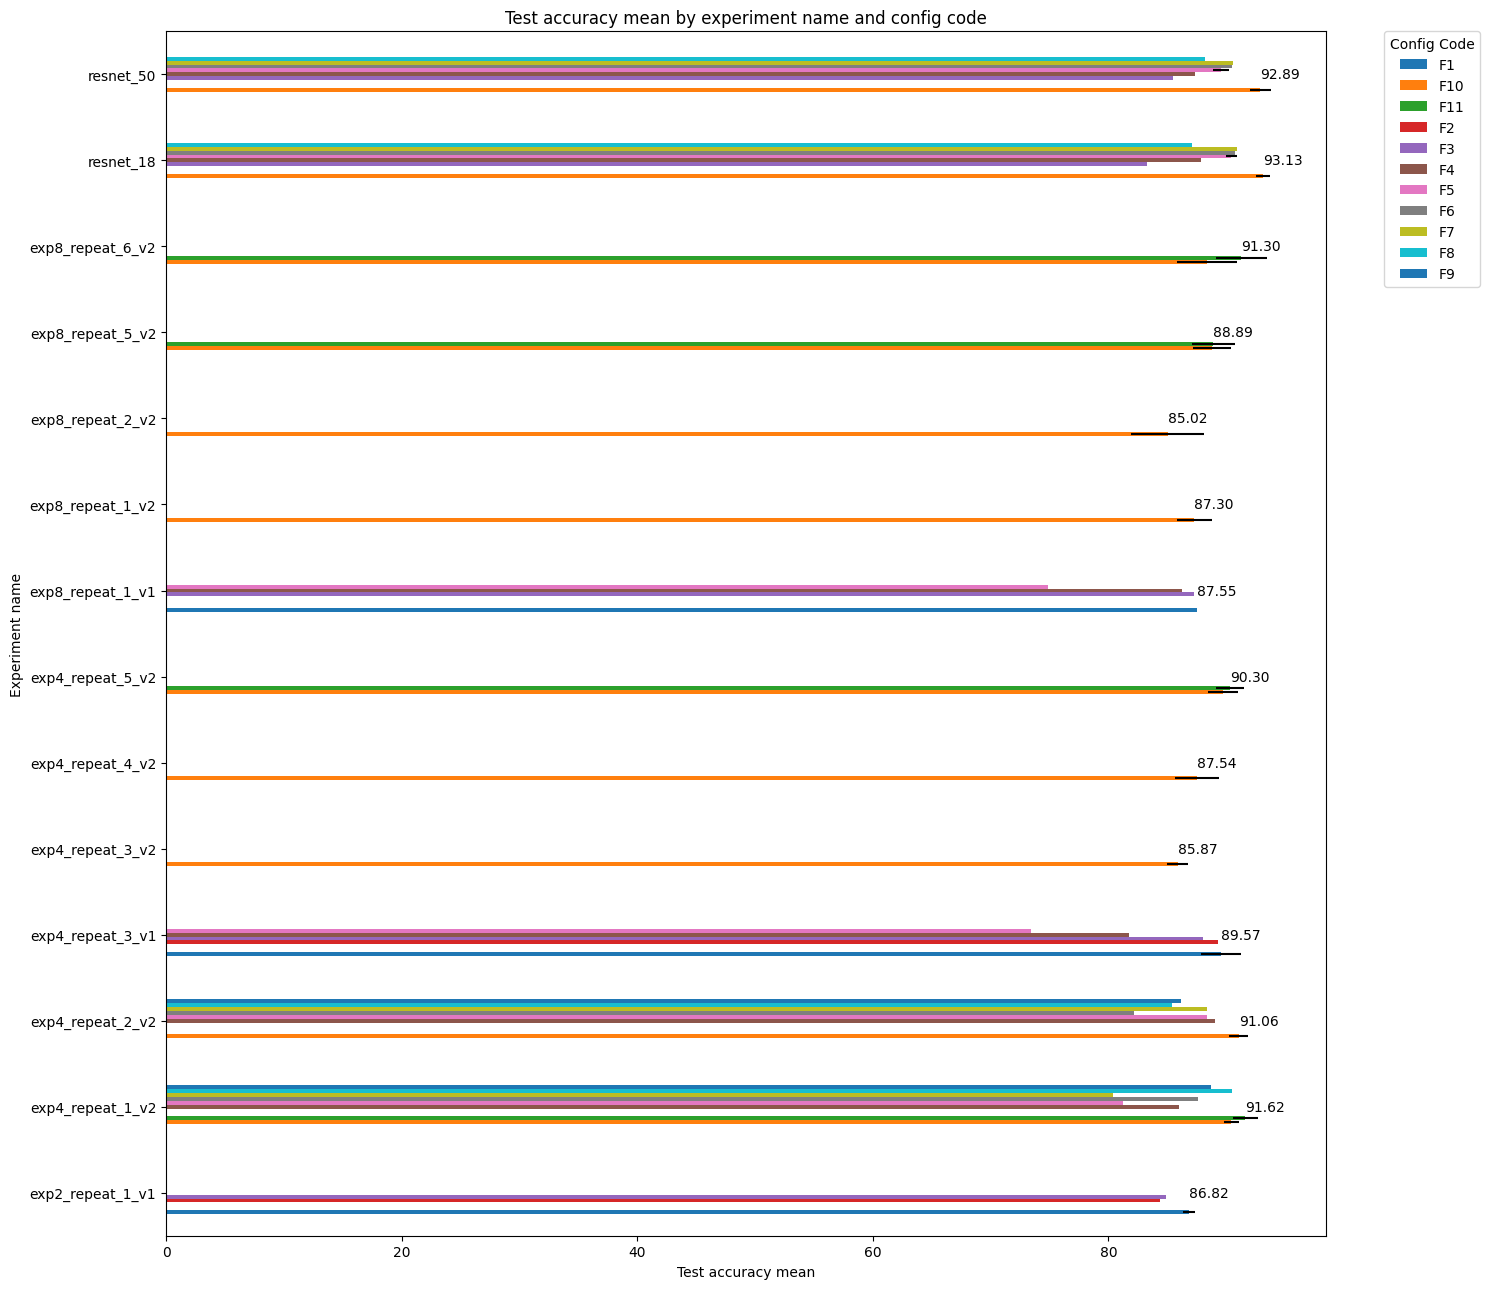

In [88]:
# group by experiment_name and config_code and plot the test acc mean
tracking_experiments_grouped = tracking_experiments.groupby(['experiment_name', 'config_code'])

fig, ax = plt.subplots(figsize=(15, 13))
tracking_experiments_grouped['test_acc_mean'].mean().unstack().plot(
    kind='barh', ax=ax, xerr=tracking_experiments_grouped['test_acc_std'].mean().unstack()
)

ax.set_xlabel('Test accuracy mean')
ax.set_ylabel('Experiment name')
ax.set_title('Test accuracy mean by experiment name and config code')

# show the max test acc mean by experiment_name and show it in the plot per bar
for i, v in enumerate(tracking_experiments_grouped['test_acc_mean'].mean().unstack().max(axis=1)):
    ax.text(v, i, f'{v:.2f}', va='center')

# Move the legend outside the plot
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title='Config Code')
plt.tight_layout()
plt.show()

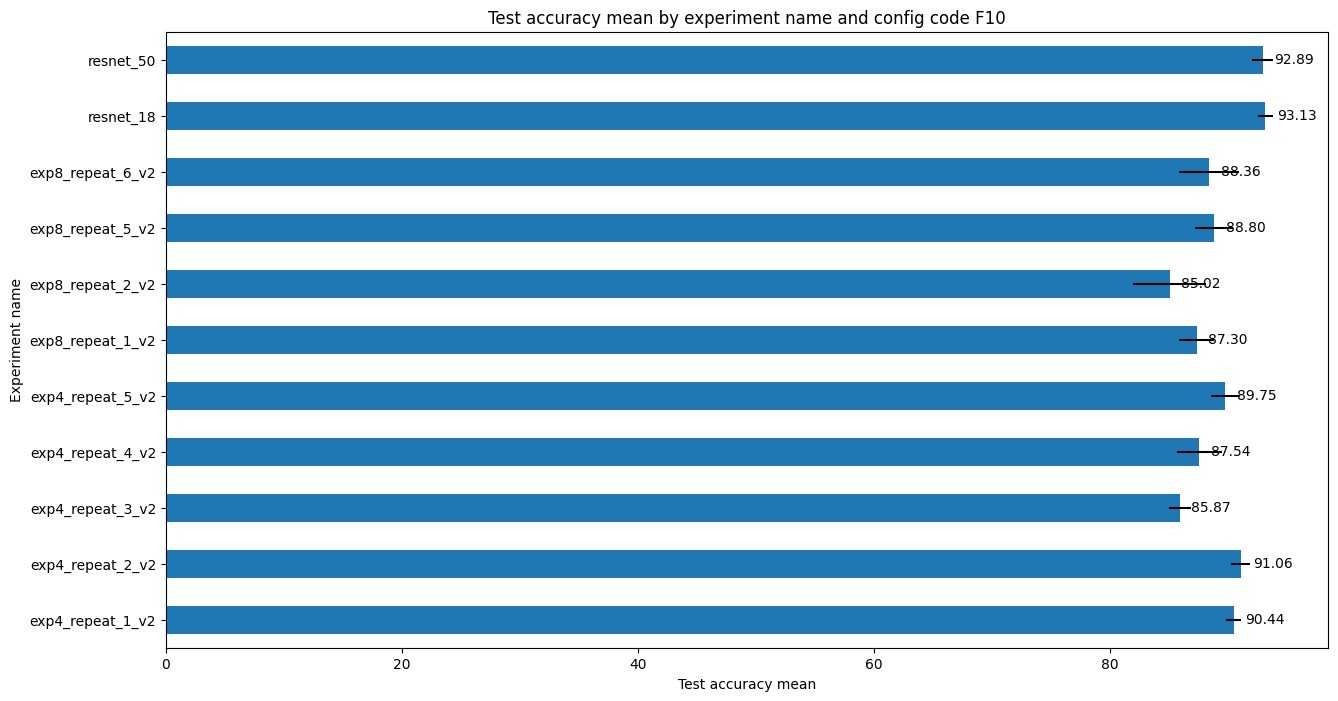

In [89]:
# group experiments by F10 config code
tracking_experiments_F10 = tracking_experiments[tracking_experiments['config_code'] == 'F10']
tracking_experiments_F10_grouped = tracking_experiments_F10.groupby(['experiment_name'])

# plot the test acc mean by experiment_name and config_code in horizontal bar plot
fig, ax = plt.subplots(figsize=(15, 8))
tracking_experiments_F10_grouped['test_acc_mean'].mean().plot(kind='barh', ax=ax, xerr=tracking_experiments_F10_grouped['test_acc_std'].mean())
ax.set_xlabel('Test accuracy mean')
ax.set_ylabel('Experiment name')
ax.set_title('Test accuracy mean by experiment name and config code F10')
# show the max value of each bar in the plot
for i, v in enumerate(tracking_experiments_F10_grouped['test_acc_mean'].mean()):
    ax.text(v+1, i, f'{v:.2f}', va='center')
plt.show()

## Plot Results

## Baseline Resnet 18 and Resnet 50

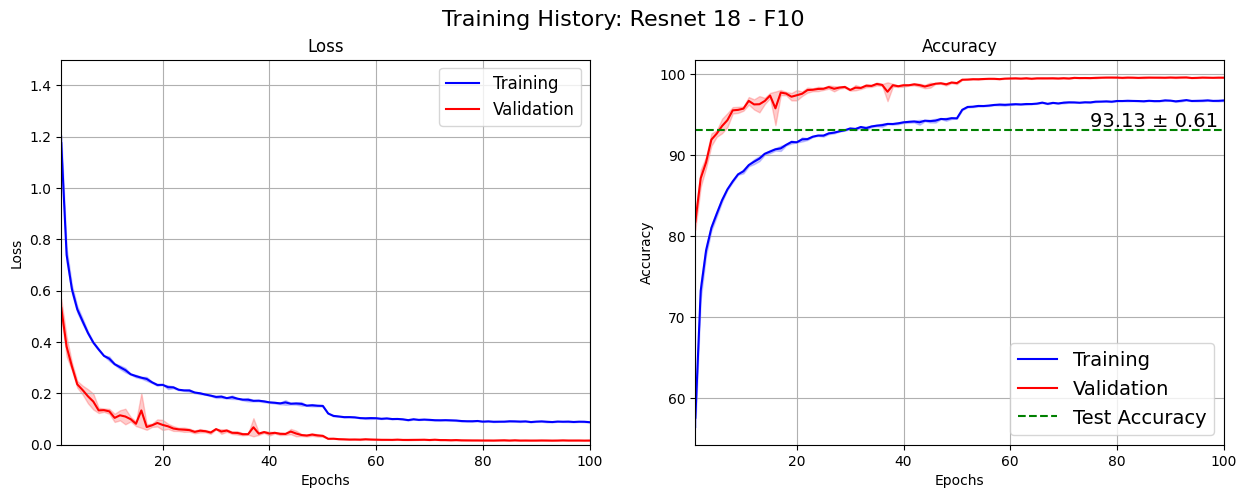

In [107]:
experiment_path_1 = os.path.join("experiments_pathmist_v2", "resnet_18")
data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F10_multistep.txt')
plot_training_history(data_dict, retrain=True, title="Resnet 18 - F10")


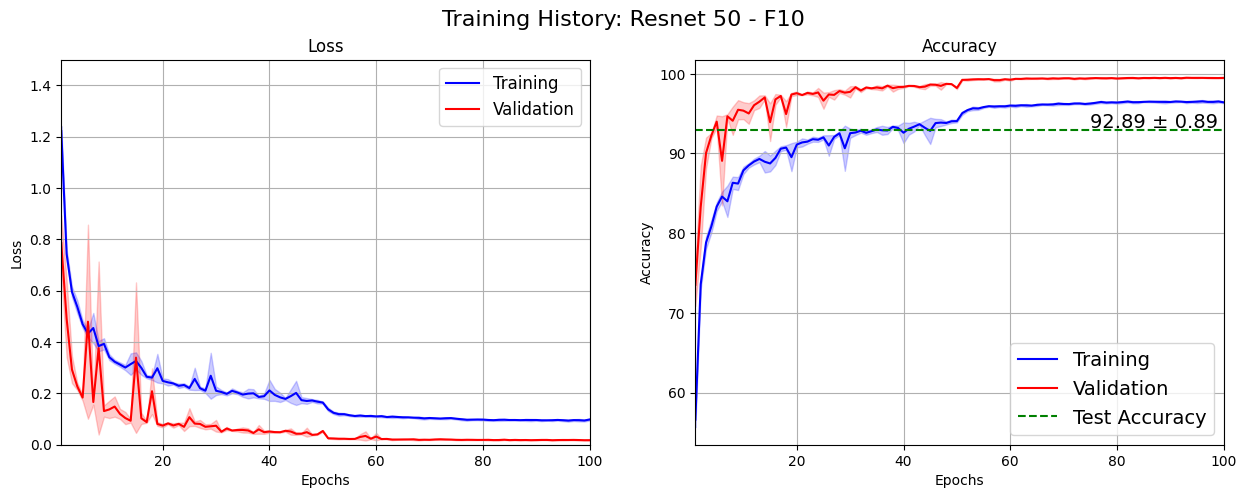

In [91]:
experiment_path_1 = os.path.join("experiments_pathmist_v2", "resnet_50")
data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F10_multistep.txt')
plot_training_history(data_dict, retrain=True, title="Resnet 50 - F10")

## Experiment-V2: Experiment 2

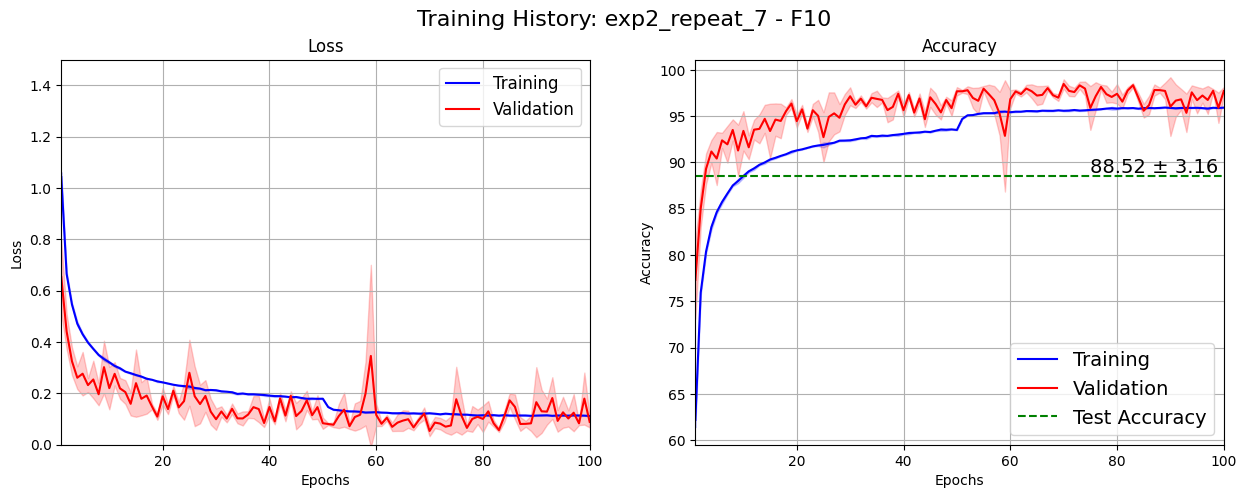

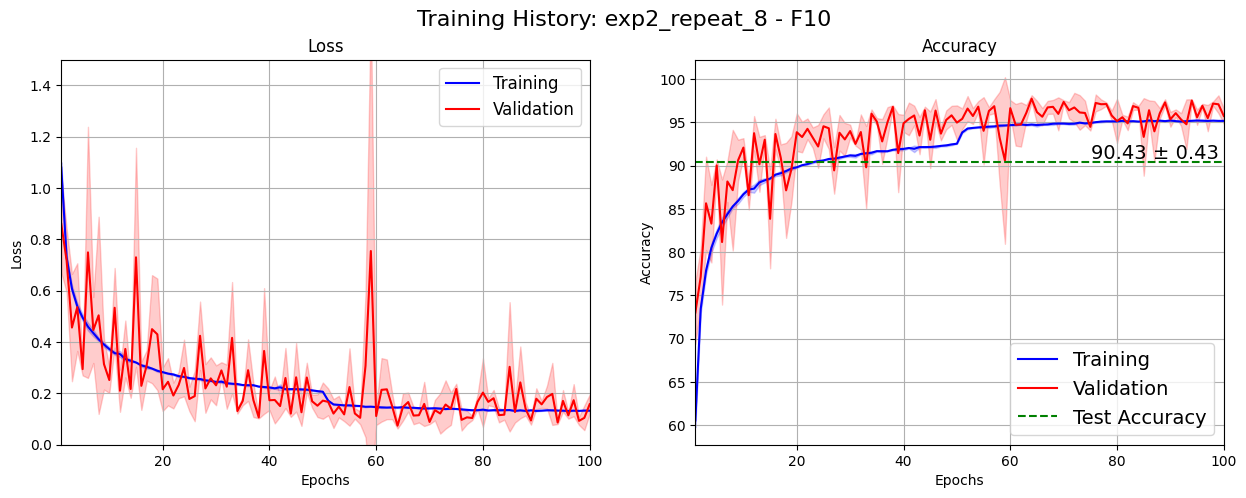

In [ ]:
experiment_name = ["exp2_repeat_7","exp2_repeat_8" ]
for name in experiment_name:
    experiment_path_1 = os.path.join("experiments_pathmist_v2", name)
    data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F10_multistep.txt')
    plot_training_history(data_dict, retrain=True, title=f"{name} - F10")

## Configuration F11

F11 = F10 + 200 epochs

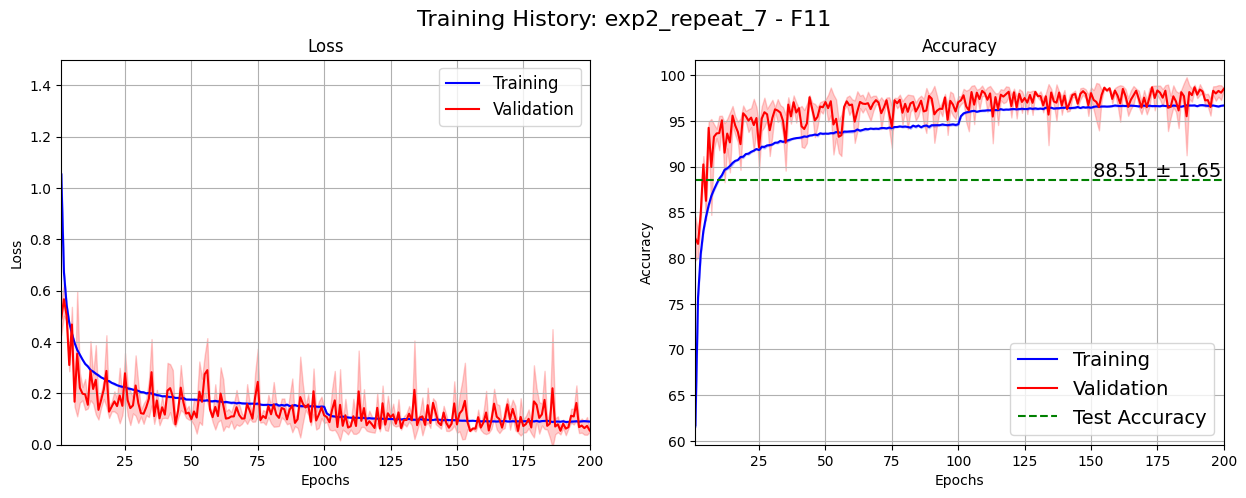

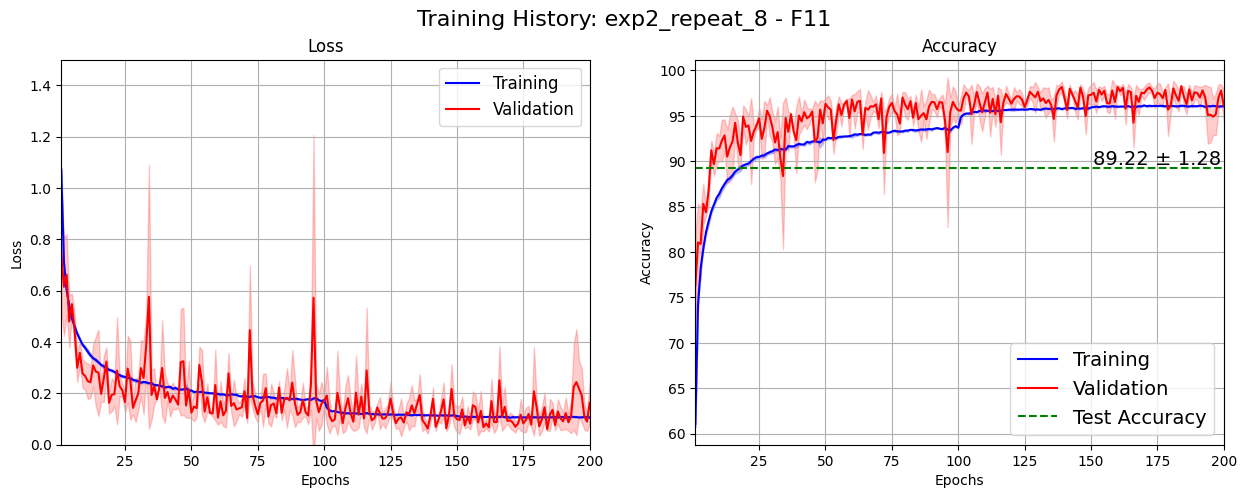

In [108]:
experiment_name = ["exp2_repeat_7","exp2_repeat_8" ]
for name in experiment_name:
    experiment_path_1 = os.path.join("experiments_pathmist_v2", name)
    data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F11_multistep.txt')
    plot_training_history(data_dict, retrain=True, title=f"{name} - F11")

## Experiment-V2: Experiment 4 

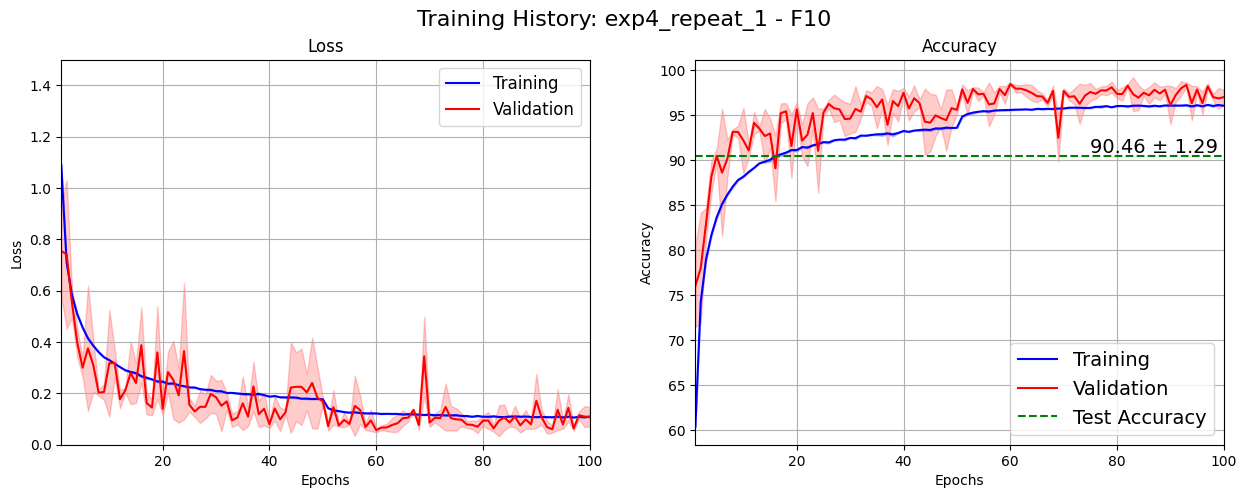

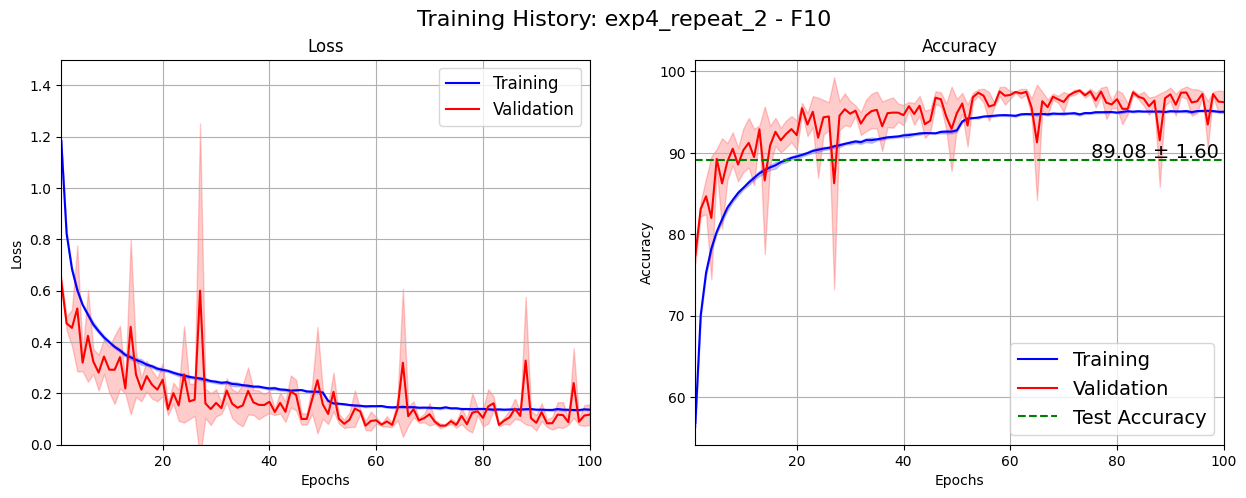

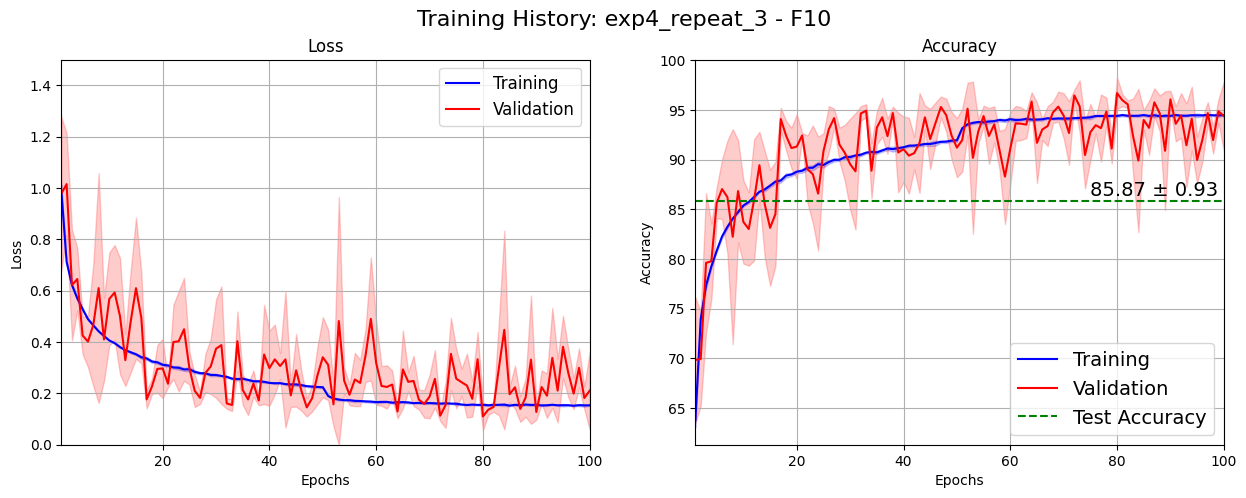

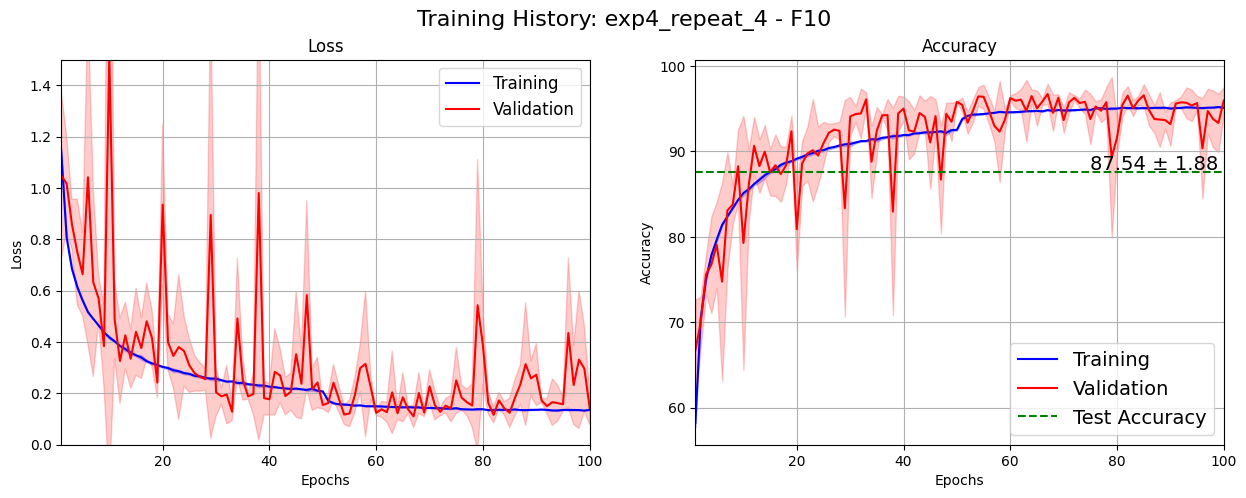

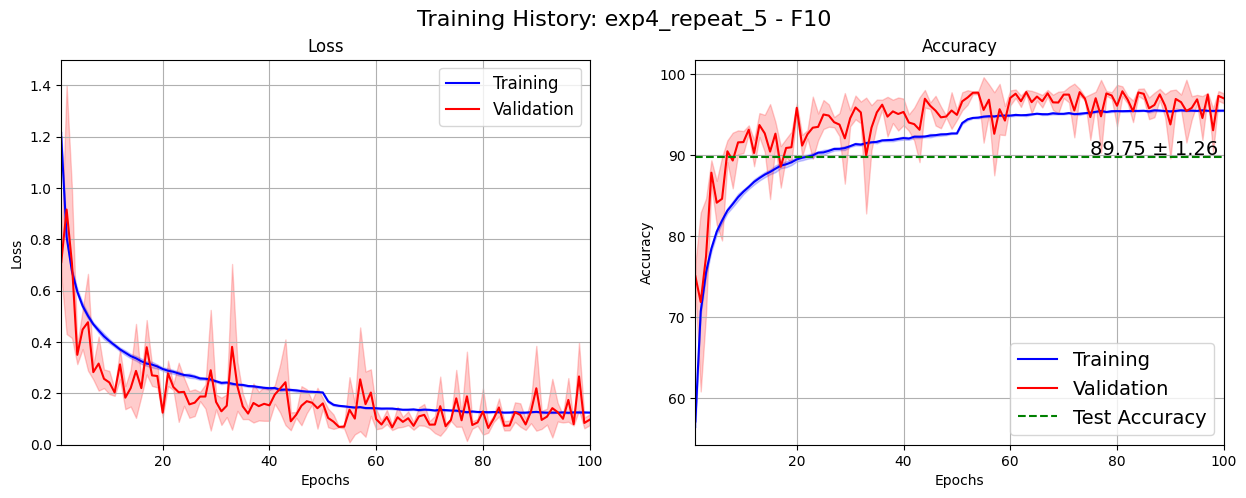

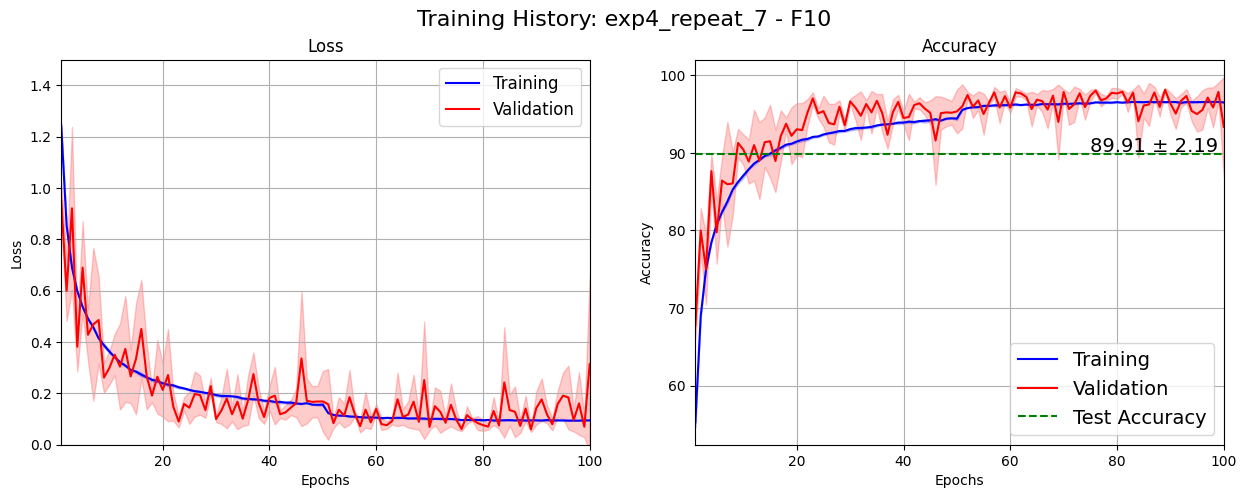

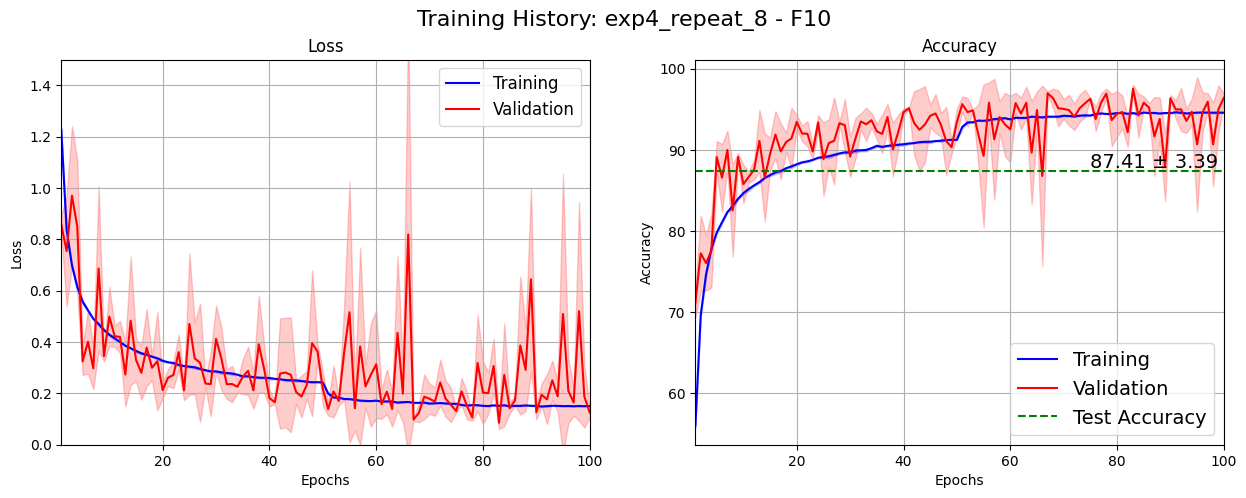

In [48]:
experiment_name = ["exp4_repeat_1", "exp4_repeat_2", "exp4_repeat_3", "exp4_repeat_4", "exp4_repeat_5", "exp4_repeat_7", "exp4_repeat_8"]
for name in experiment_name:
    experiment_path_1 = os.path.join("experiments_pathmist_v2", name)
    data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F10_multistep.txt')
    plot_training_history(data_dict, retrain=True, title=f"{name} - F10")


## Configuration F11

F11 = F10 + 200 epochs

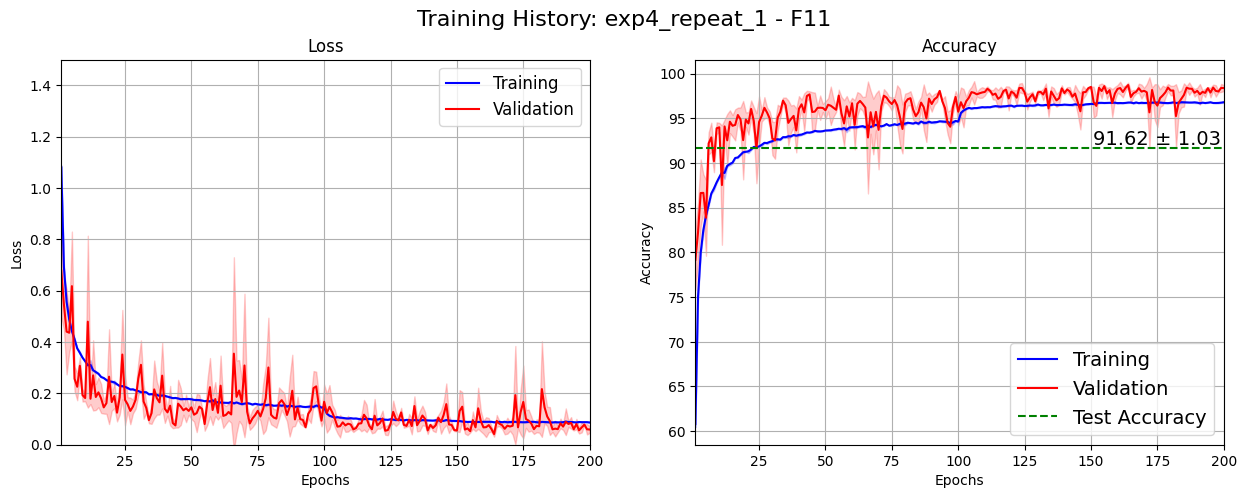

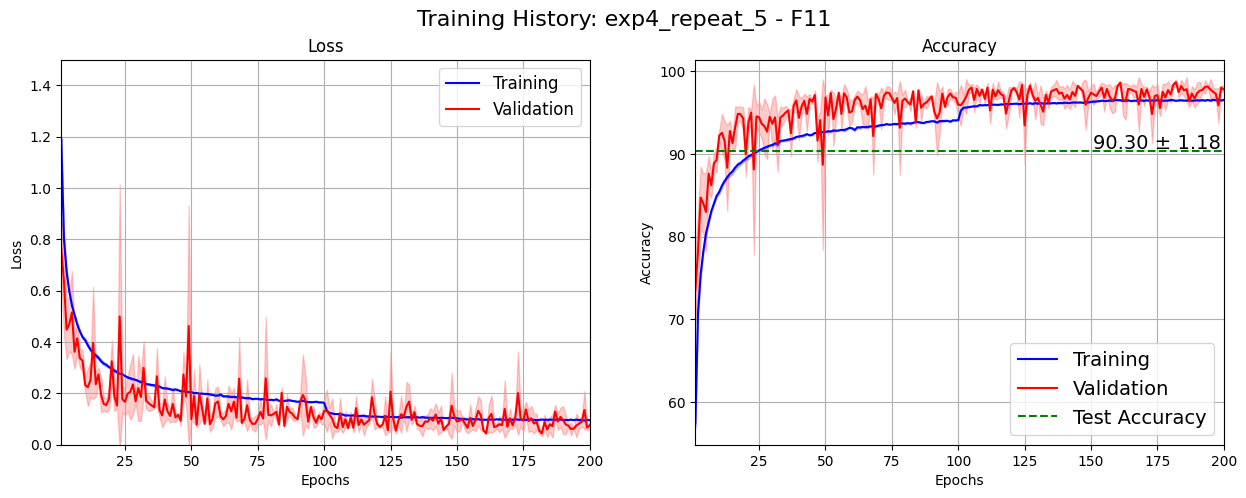

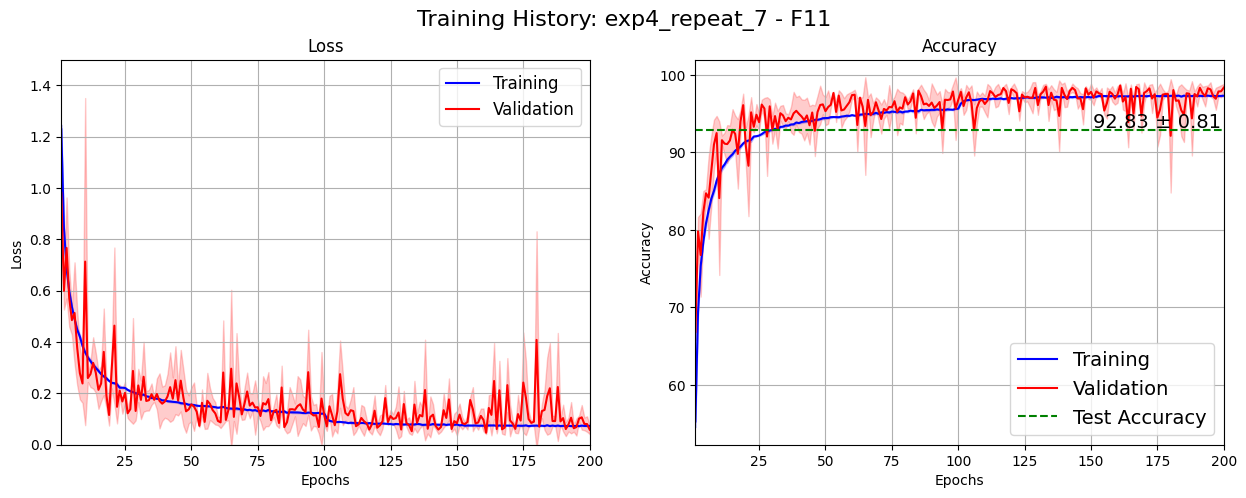

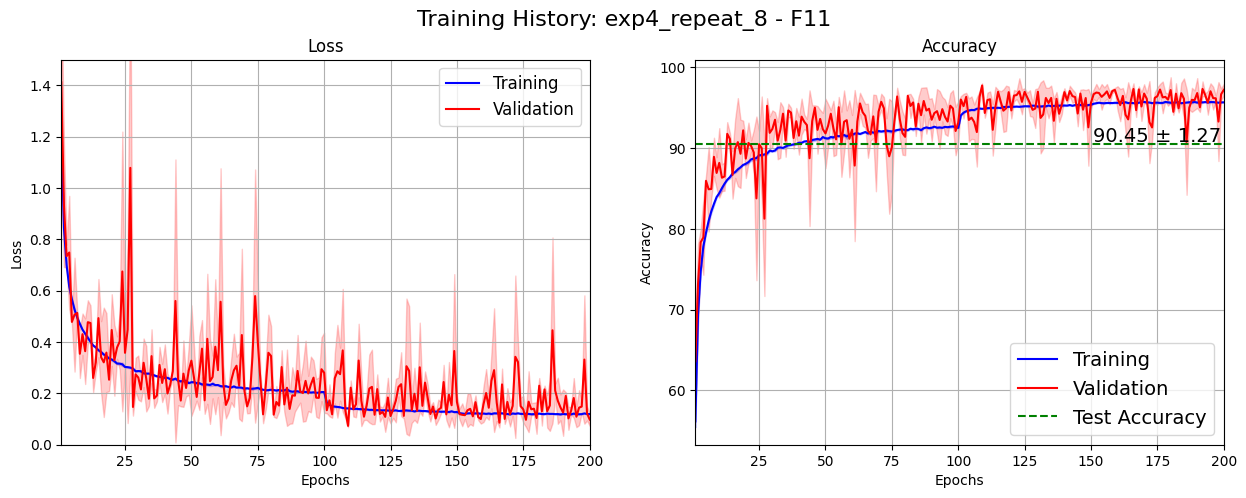

In [49]:
experiment_name = [ "exp4_repeat_1", "exp4_repeat_5", "exp4_repeat_7", "exp4_repeat_8"]
for name in experiment_name:
    experiment_path_1 = os.path.join("experiments_pathmist_v2", name)
    data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F11_multistep.txt')
    plot_training_history(data_dict, retrain=True, title=f"{name} - F11")

## Experiment-V2: Experiment 7

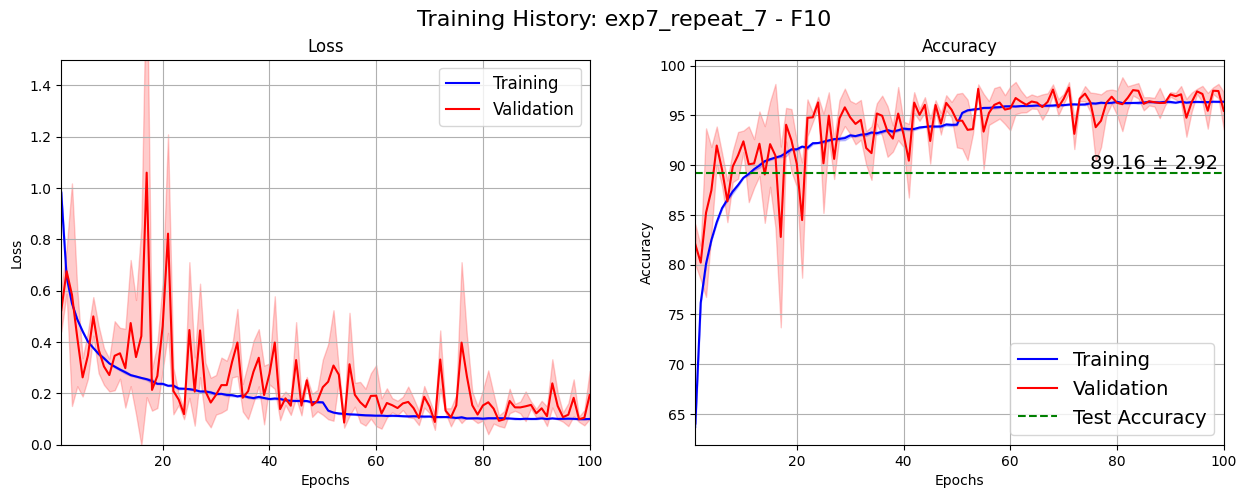

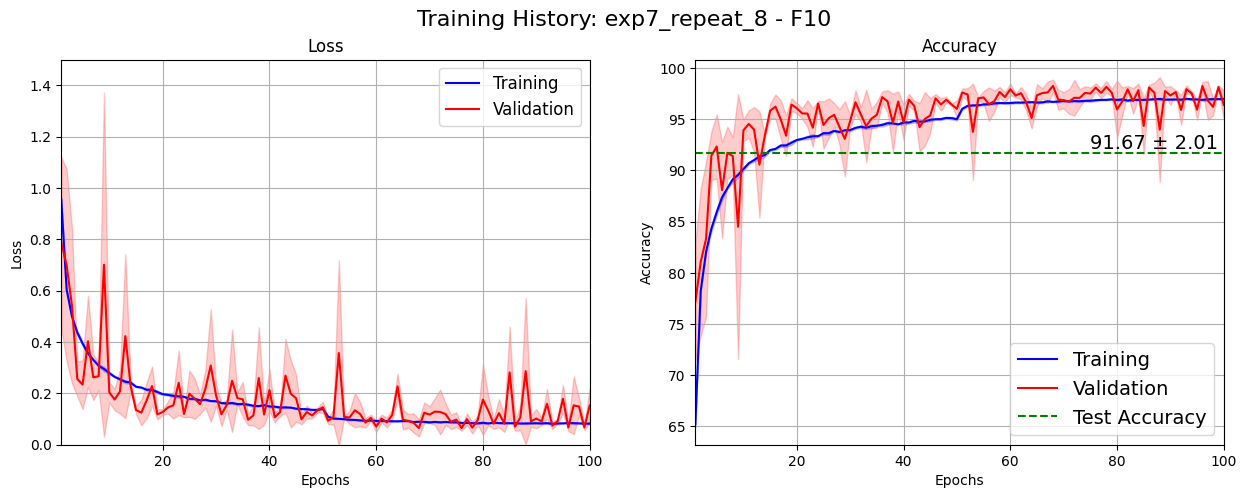

In [52]:
experiment_name = ["exp7_repeat_7","exp7_repeat_8" ]
for name in experiment_name:
    experiment_path_1 = os.path.join("experiments_pathmist_v2", name)
    data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F10_multistep.txt')
    plot_training_history(data_dict, retrain=True, title=f"{name} - F10")

## Configuration F11

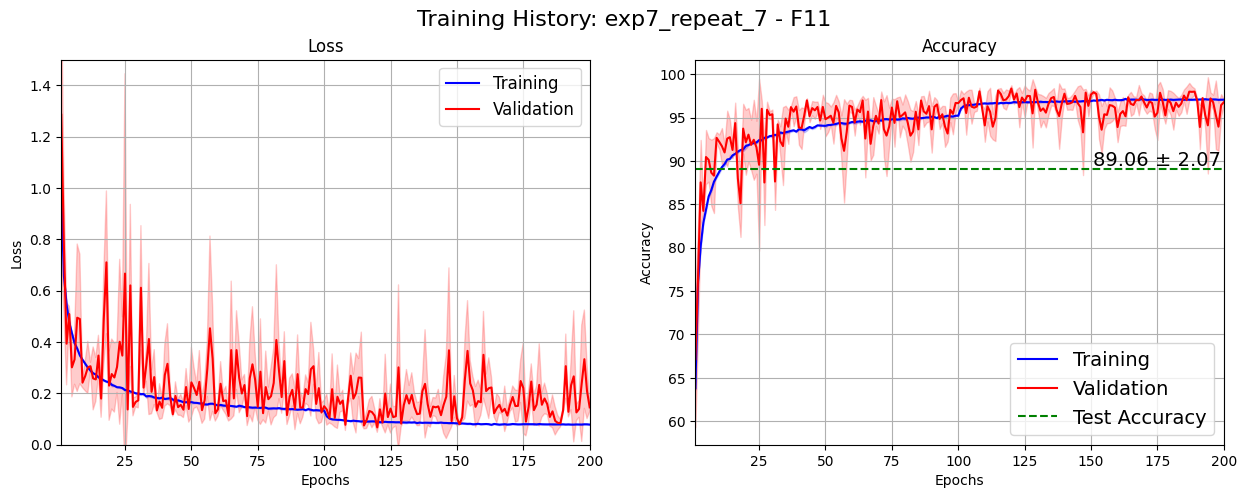

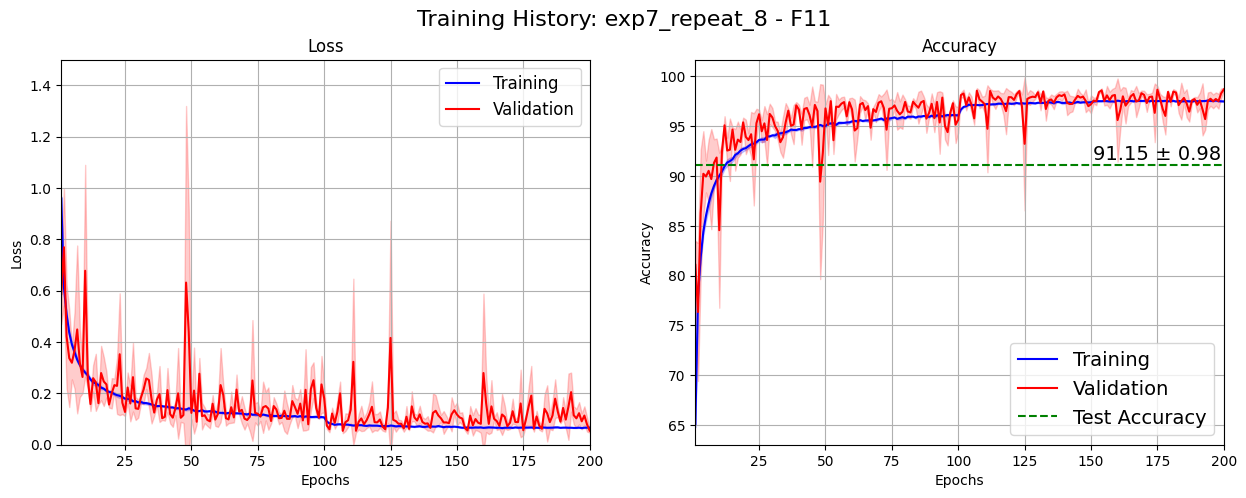

In [53]:
experiment_name = ["exp7_repeat_7","exp7_repeat_8" ]
for name in experiment_name:
    experiment_path_1 = os.path.join("experiments_pathmist_v2", name)
    data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F11_multistep.txt')
    plot_training_history(data_dict, retrain=True, title=f"{name} - F11")

## Experiment-V2: Experiment 8

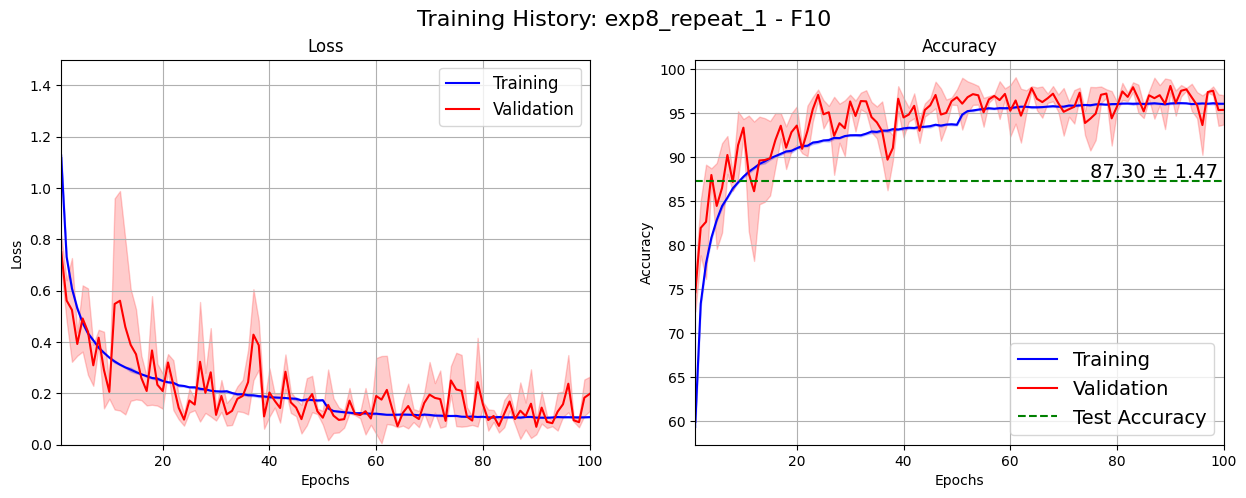

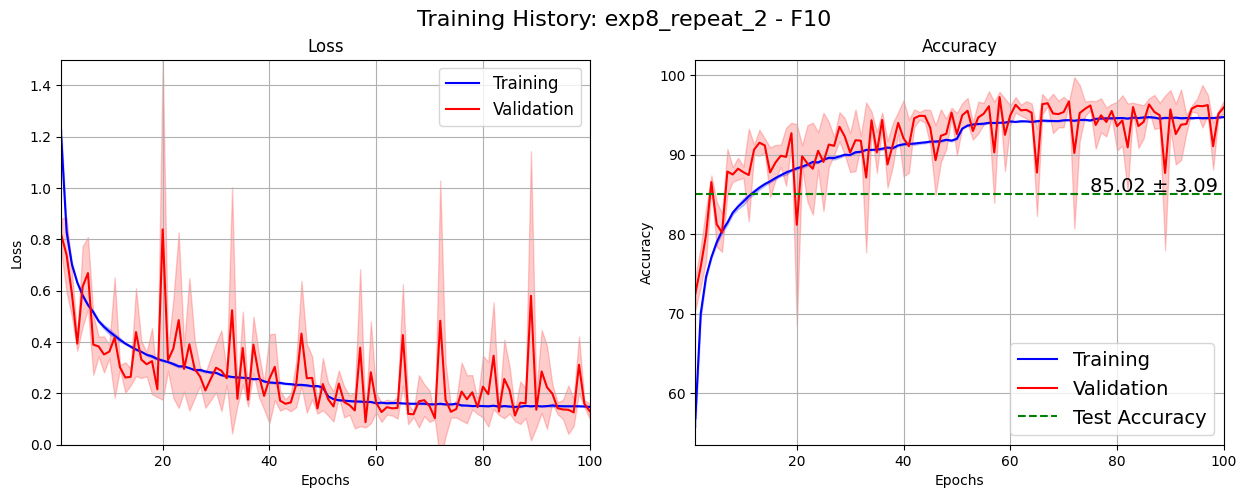

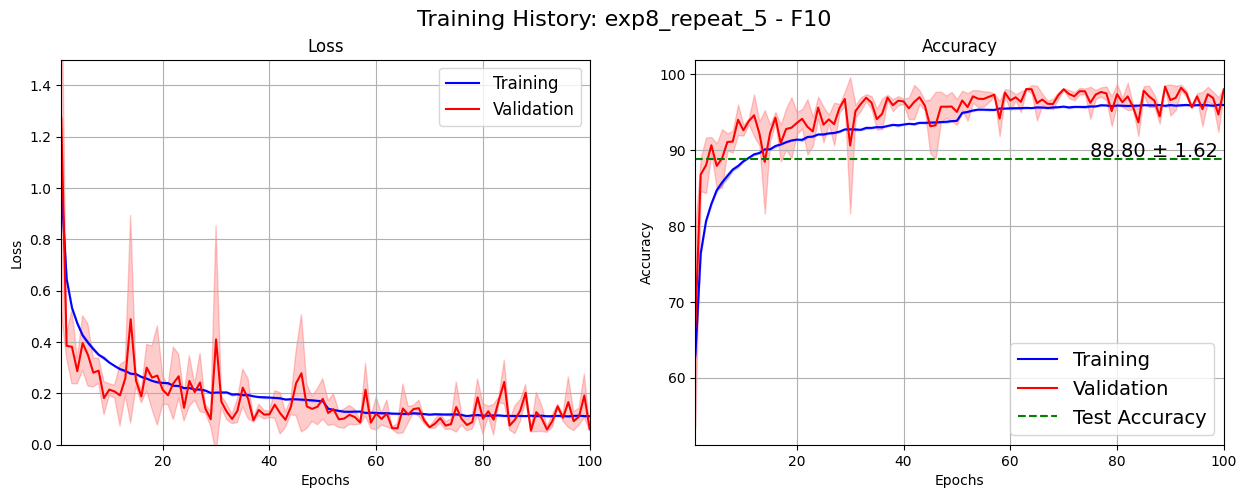

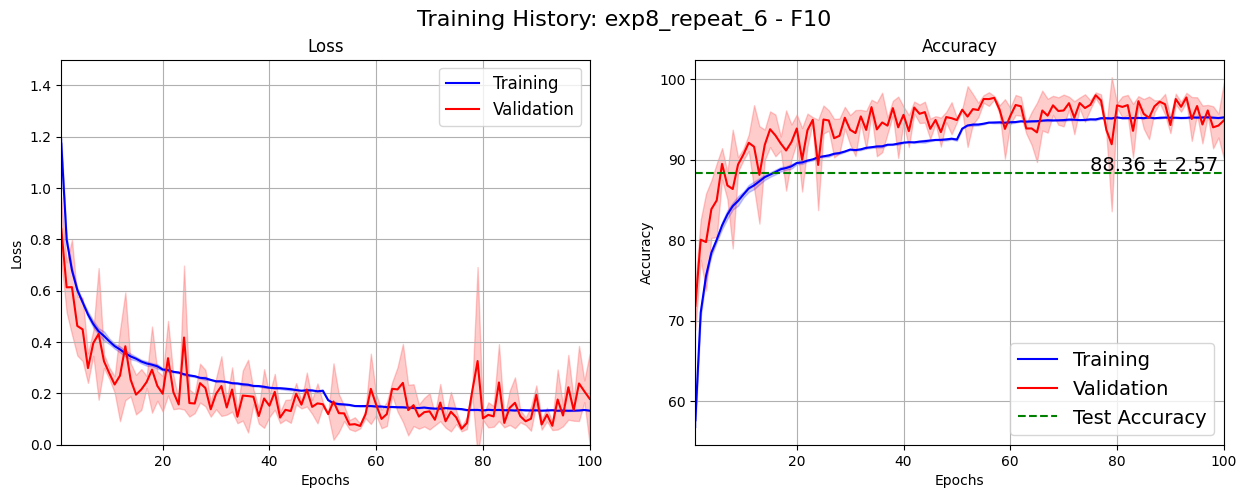

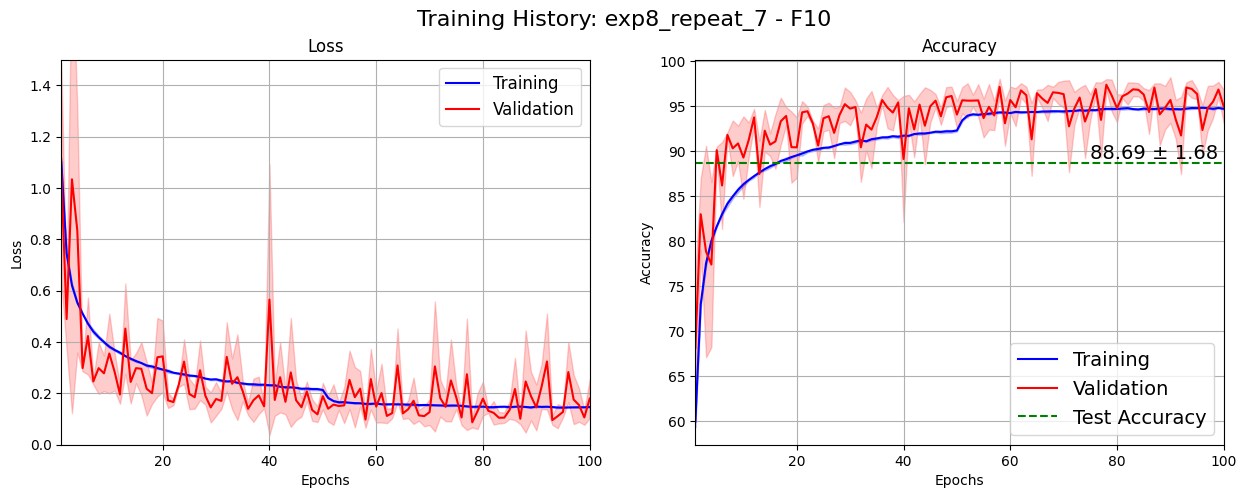

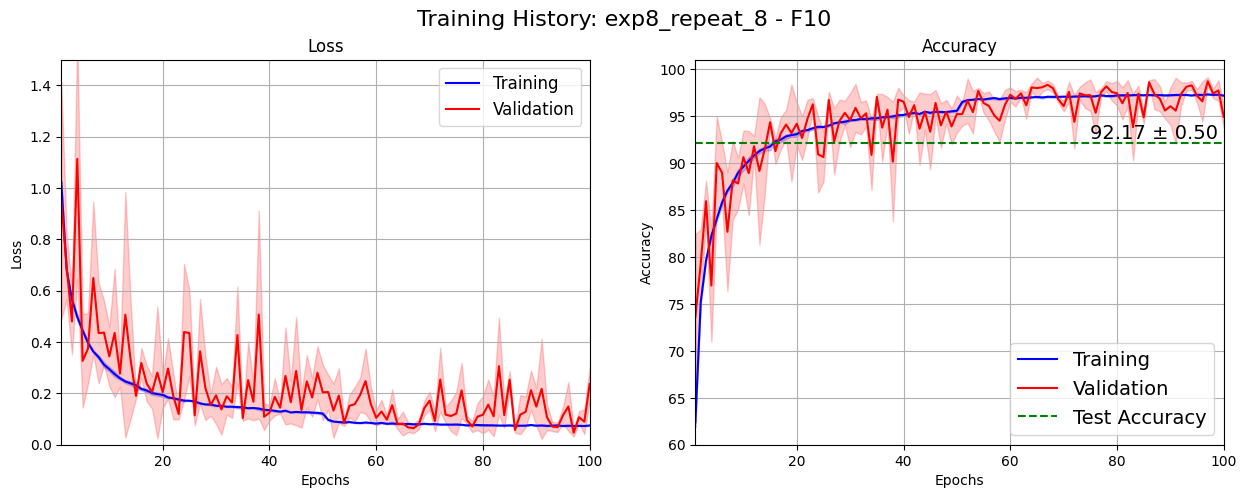

In [44]:
experiment_name = ["exp8_repeat_1", "exp8_repeat_2", "exp8_repeat_5", "exp8_repeat_6", "exp8_repeat_7", "exp8_repeat_8"]
for name in experiment_name:
    experiment_path_1 = os.path.join("experiments_pathmist_v2", name)
    data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F10_multistep.txt')
    plot_training_history(data_dict, retrain=True, title=f"{name} - F10")

## Configuration F11

F10: + 200 epochs


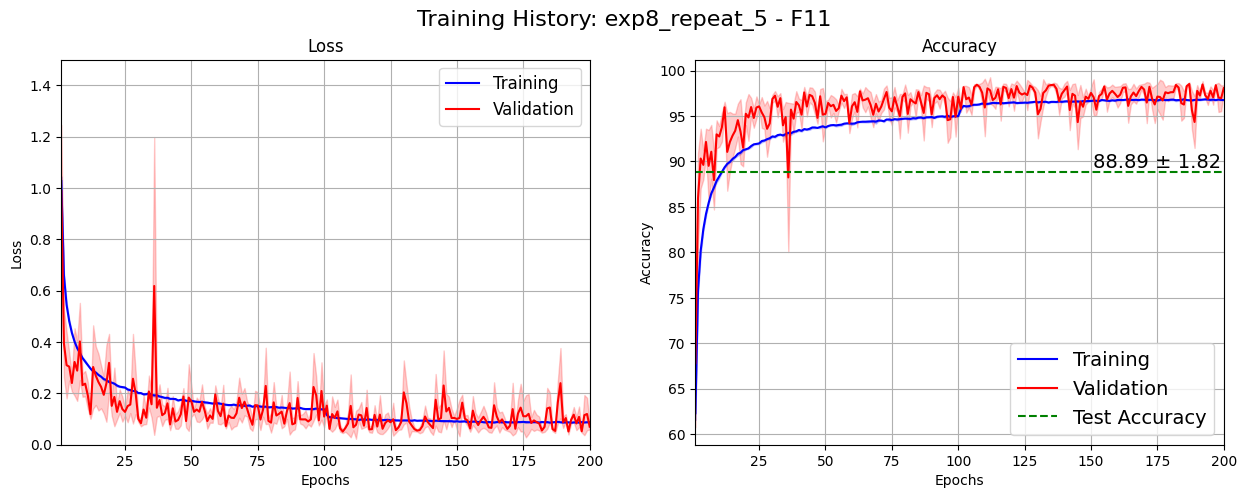

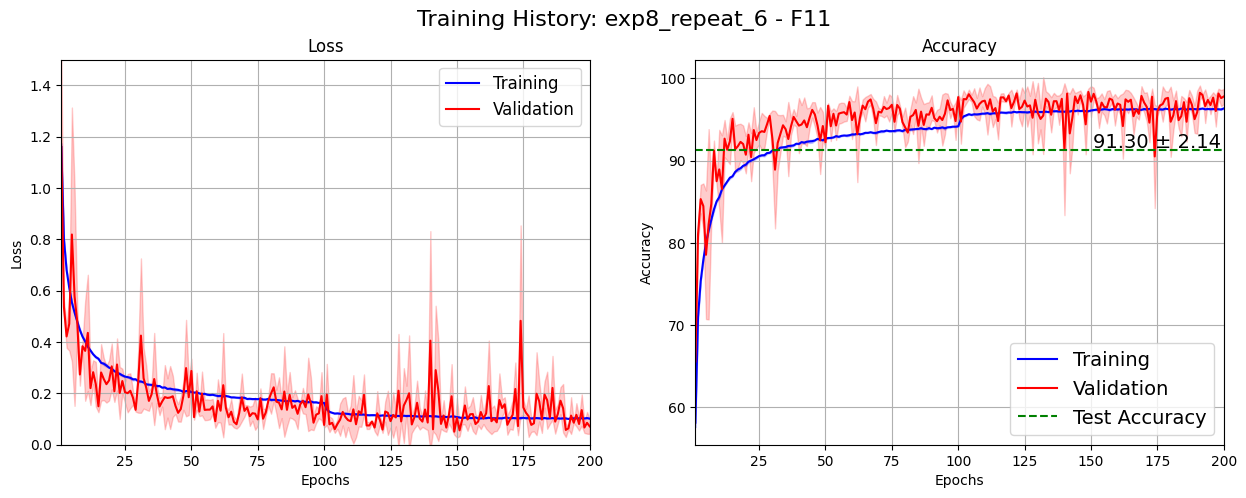

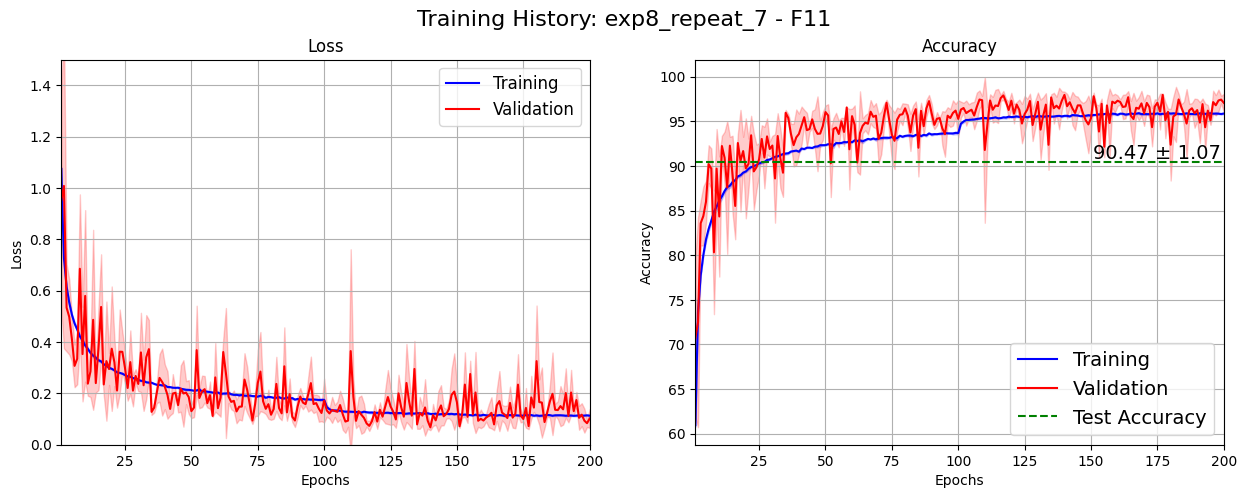

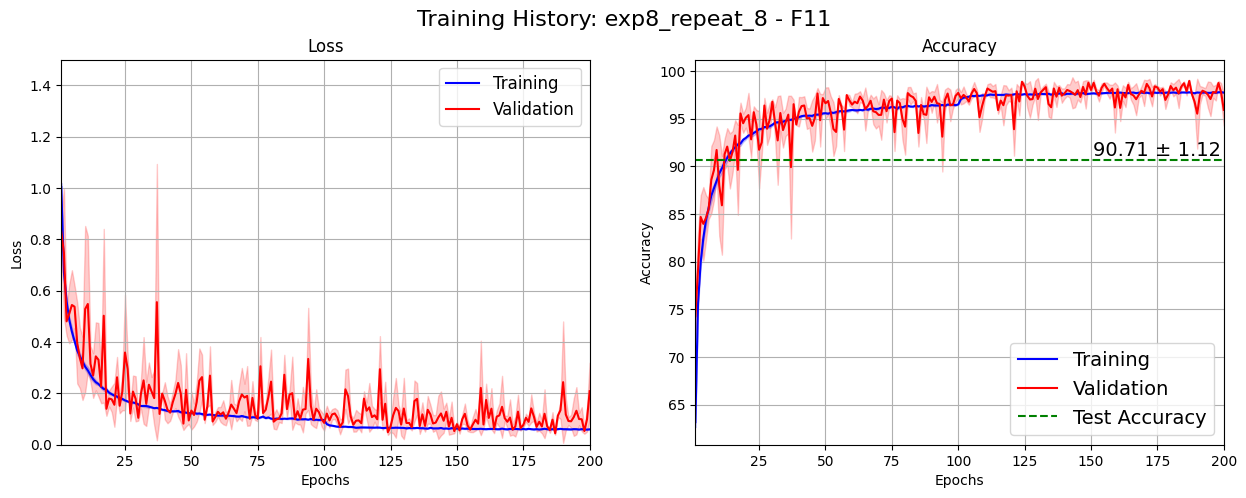

In [47]:
experiment_name = [ "exp8_repeat_5", "exp8_repeat_6", "exp8_repeat_7", "exp8_repeat_8"]
for name in experiment_name:
    experiment_path_1 = os.path.join("experiments_pathmist_v2", name)
    data_dict = load_retrain_results(experiment_path_1, 'retrain_results_F11_multistep.txt')
    plot_training_history(data_dict, retrain=True, title=f"{name} - F11")

## Experiment 1: Baseline Model

- Configuration: config_files_med/config1.txt

### Repetition 1 - 3

In [27]:
experiment_path_1 = os.path.join("experiments_pathmist", "exp1_repeat_1")
experiment_path_2 = os.path.join("experiments_pathmist", "exp1_repeat_2")
experiment_path_3 = os.path.join("experiments_pathmist", "exp1_repeat_3")

data_r1 = load_retrain_results(experiment_path_1, 'retrain_results.txt')
data_r2 = load_retrain_results(experiment_path_2, 'retrain_results.txt')
data_r3 = load_retrain_results(experiment_path_3, 'retrain_results.txt')
evolved_r1 = load_evolved_data(experiment_path_1)
evolved_r2 = load_evolved_data(experiment_path_2)
evolved_r3 = load_evolved_data(experiment_path_3)

best_fitness_r1 = evolved_r1['best_accuracy']
best_fitness_r2 = evolved_r2['best_accuracy']
best_fitness_r3 = evolved_r3['best_accuracy']

In [28]:
# for key in data_r1.keys():
#     plot_training_history(data_r1[key], params=args, retrain=True)

In [29]:
experiments_names = ['exp1_repeat_1', 'exp1_repeat_2', 'exp1_repeat_3']
best_fitness = [best_fitness_r1, best_fitness_r2, best_fitness_r3]
acc_r1 = [data_r1[key]['acc_medmnist'] for key in data_r1.keys()]
auc_r1 = [data_r1[key]['auc_score'] for key in data_r1.keys()]
acc_r2 = [data_r2[key]['acc_medmnist'] for key in data_r2.keys()]
auc_r2 = [data_r2[key]['auc_score'] for key in data_r2.keys()]
acc_r3 = [data_r3[key]['acc_medmnist'] for key in data_r3.keys()]
auc_r3 = [data_r3[key]['auc_score'] for key in data_r3.keys()]

# reorganize the results
acc_r1 = [acc_r1[0], acc_r2[0], acc_r3[0]]
acc_r2 = [acc_r1[1], acc_r2[1], acc_r3[1]]
acc_r3 = [acc_r1[2], acc_r2[2], acc_r3[2]]

auc_r1 = [auc_r1[0], auc_r2[0], auc_r3[0]]
auc_r2 = [auc_r1[1], auc_r2[1], auc_r3[1]]
auc_r3 = [auc_r1[2], auc_r2[2], auc_r3[2]]

# create a dictionary with the results
results = {
    'experiment': experiments_names,
    'best_fitness': best_fitness,
    'acc_rep1': acc_r1,
    'acc_rep2': acc_r2,
    'acc_rep3': acc_r3,
    'auc_rep1': auc_r1,
    'auc_rep2': auc_r2,
    'auc_rep3': auc_r3,    
}

# create a dataframe with the results
df_exp1 = pd.DataFrame(results)

In [30]:
# create a new column with the max accuracy between the acc_r1, acc_r2 and acc_r3 per row
df_exp1['max_acc'] = df_exp1[['acc_rep1', 'acc_rep2', 'acc_rep3']].max(axis=1)
df_exp1['mean_acc'] = df_exp1[['acc_rep1', 'acc_rep2', 'acc_rep3']].mean(axis=1)
df_exp1['max_auc'] = df_exp1[['auc_rep1', 'auc_rep2', 'auc_rep3']].max(axis=1)
df_exp1['mean_auc'] = df_exp1[['auc_rep1', 'auc_rep2', 'auc_rep3']].mean(axis=1)
df_exp1

,experiment,best_fitness,acc_rep1,acc_rep2,acc_rep3,auc_rep1,auc_rep2,auc_rep3,max_acc,mean_acc,max_auc,mean_auc
0,exp1_repeat_1,88.088088,0.872563,0.856407,0.859889,0.988006,0.987598,0.984850,0.872563,0.862953,0.988006,0.986818
1,exp1_repeat_2,88.388388,0.856407,0.871031,0.874234,0.987598,0.986793,0.984219,0.874234,0.867224,0.987598,0.986204
2,exp1_repeat_3,87.287287,0.859889,0.874234,0.883008,0.984850,0.984219,0.990082,0.883008,0.872377,0.990082,0.986384


## Experiment 2: Convolutional Blocks Extended

- Configuration: config_files_med/config2.txt

### Repetition 1 - 3

In [31]:
experiment_path_1 = os.path.join("experiments_pathmist", "exp2_repeat_1")
experiment_path_2 = os.path.join("experiments_pathmist", "exp2_repeat_2")
experiment_path_3 = os.path.join("experiments_pathmist", "exp2_repeat_3")

data_r1 = load_retrain_results(experiment_path_1, 'retrain_results.txt')
data_r2 = load_retrain_results(experiment_path_2, 'retrain_results.txt')
data_r3 = load_retrain_results(experiment_path_3, 'retrain_results.txt')
evolved_r1 = load_evolved_data(experiment_path_1)
evolved_r2 = load_evolved_data(experiment_path_2)
evolved_r3 = load_evolved_data(experiment_path_3)

best_fitness_r1 = evolved_r1['best_accuracy']
best_fitness_r2 = evolved_r2['best_accuracy']
best_fitness_r3 = evolved_r3['best_accuracy']

FileNotFoundError: [Errno 2] No such file or directory: 'experiments_pathmist/exp2_repeat_1/retrain_results.txt'

In [ ]:
# experiment_path_1 = os.path.join("experiments_pathmist", "exp2_repeat_1")
# data_r1 = load_retrain_results(experiment_path_1, 'retrain_results.txt')

# for key in data_r1.keys():
#     plot_training_history(data_r1[key], params=args, retrain=True)

In [ ]:
experiments_names = ['exp2_repeat_1', 'exp2_repeat_2', 'exp2_repeat_3']
best_fitness = [best_fitness_r1, best_fitness_r2, best_fitness_r3]
acc_r1 = [data_r1[key]['acc_medmnist'] for key in data_r1.keys()]
auc_r1 = [data_r1[key]['auc_score'] for key in data_r1.keys()]
acc_r2 = [data_r2[key]['acc_medmnist'] for key in data_r2.keys()]
auc_r2 = [data_r2[key]['auc_score'] for key in data_r2.keys()]
acc_r3 = [data_r3[key]['acc_medmnist'] for key in data_r3.keys()]
auc_r3 = [data_r3[key]['auc_score'] for key in data_r3.keys()]

# reorganize the results
acc_r1 = [acc_r1[0], acc_r2[0], acc_r3[0]]
acc_r2 = [acc_r1[1], acc_r2[1], acc_r3[1]]
acc_r3 = [acc_r1[2], acc_r2[2], acc_r3[2]]

auc_r1 = [auc_r1[0], auc_r2[0], auc_r3[0]]
auc_r2 = [auc_r1[1], auc_r2[1], auc_r3[1]]
auc_r3 = [auc_r1[2], auc_r2[2], auc_r3[2]]

# create a dictionary with the results
results = {
    'experiment': experiments_names,
    'best_fitness': best_fitness,
    'acc_rep1': acc_r1,
    'acc_rep2': acc_r2,
    'acc_rep3': acc_r3,
    'auc_rep1': auc_r1,
    'auc_rep2': auc_r2,
    'auc_rep3': auc_r3,  
    
}

# create a dataframe with the results
df_exp2 = pd.DataFrame(results)

In [ ]:
# create a new column with the max accuracy between the acc_r1, acc_r2 and acc_r3 per row
df_exp2['max_acc'] = df_exp2[['acc_rep1', 'acc_rep2', 'acc_rep3']].max(axis=1)
df_exp2['mean_acc'] = df_exp2[['acc_rep1', 'acc_rep2', 'acc_rep3']].mean(axis=1)
df_exp2['max_auc'] = df_exp2[['auc_rep1', 'auc_rep2', 'auc_rep3']].max(axis=1)
df_exp2['mean_auc'] = df_exp2[['auc_rep1', 'auc_rep2', 'auc_rep3']].mean(axis=1)
df_exp2

,experiment,best_fitness,acc_rep1,acc_rep2,acc_rep3,auc_rep1,auc_rep2,auc_rep3,max_acc,mean_acc,max_auc,mean_auc
0,exp2_repeat_1,88.888889,0.320891,0.856128,0.883844,0.702668,0.987947,0.986484,0.883844,0.686955,0.987947,0.892367
1,exp2_repeat_2,88.888889,0.856128,0.883148,0.875070,0.987947,0.989791,0.989870,0.883148,0.871448,0.989870,0.989203
2,exp2_repeat_3,88.888889,0.883844,0.875070,0.852368,0.986484,0.989870,0.985564,0.883844,0.870427,0.989870,0.987306


## Experiment 3: Depht Wise Separable Convolutional Blocks Extended

- Configuration: config_files_med/config3.txt

### Repetition 1 - 3

In [ ]:
experiment_path_1 = os.path.join("experiments_pathmist", "exp3_repeat_1")
experiment_path_2 = os.path.join("experiments_pathmist", "exp3_repeat_2")
experiment_path_3 = os.path.join("experiments_pathmist", "exp3_repeat_3")

data_r1 = load_retrain_results(experiment_path_1, 'retrain_results.txt')
data_r2 = load_retrain_results(experiment_path_2, 'retrain_results.txt')
data_r3 = load_retrain_results(experiment_path_3, 'retrain_results.txt')
evolved_r1 = load_evolved_data(experiment_path_1)
evolved_r2 = load_evolved_data(experiment_path_2)
evolved_r3 = load_evolved_data(experiment_path_3)

best_fitness_r1 = evolved_r1['best_accuracy']
best_fitness_r2 = evolved_r2['best_accuracy']
best_fitness_r3 = evolved_r3['best_accuracy']

In [ ]:
experiments_names = ['exp3_repeat_1', 'exp3_repeat_2', 'exp3_repeat_3']
best_fitness = [best_fitness_r1, best_fitness_r2, best_fitness_r3]
acc_r1 = [data_r1[key]['acc_medmnist'] for key in data_r1.keys()]
auc_r1 = [data_r1[key]['auc_score'] for key in data_r1.keys()]
acc_r2 = [data_r2[key]['acc_medmnist'] for key in data_r2.keys()]
auc_r2 = [data_r2[key]['auc_score'] for key in data_r2.keys()]
acc_r3 = [data_r3[key]['acc_medmnist'] for key in data_r3.keys()]
auc_r3 = [data_r3[key]['auc_score'] for key in data_r3.keys()]

# reorganize the results
acc_r1 = [acc_r1[0], acc_r2[0], acc_r3[0]]
acc_r2 = [acc_r1[1], acc_r2[1], acc_r3[1]]
acc_r3 = [acc_r1[2], acc_r2[2], acc_r3[2]]

auc_r1 = [auc_r1[0], auc_r2[0], auc_r3[0]]
auc_r2 = [auc_r1[1], auc_r2[1], auc_r3[1]]
auc_r3 = [auc_r1[2], auc_r2[2], auc_r3[2]]

# create a dictionary with the results
results = {
    'experiment': experiments_names,
    'best_fitness': best_fitness,
    'acc_rep1': acc_r1,
    'acc_rep2': acc_r2,
    'acc_rep3': acc_r3,
    'auc_rep1': auc_r1,
    'auc_rep2': auc_r2,
    'auc_rep3': auc_r3,  
    
}

# create a dataframe with the results
df_exp3 = pd.DataFrame(results)

In [ ]:
# create a new column with the max accuracy between the acc_r1, acc_r2 and acc_r3 per row
df_exp3['max_acc'] = df_exp3[['acc_rep1', 'acc_rep2', 'acc_rep3']].max(axis=1)
df_exp3['mean_acc'] = df_exp3[['acc_rep1', 'acc_rep2', 'acc_rep3']].mean(axis=1)
df_exp3['max_auc'] = df_exp3[['auc_rep1', 'auc_rep2', 'auc_rep3']].max(axis=1)
df_exp3['mean_auc'] = df_exp3[['auc_rep1', 'auc_rep2', 'auc_rep3']].mean(axis=1)
df_exp3

# Load old Files

To load old results files its necessary to manually remove the confusions from the file. This notebook will show how to do it.

In [ ]:
# Load data from the file using ast
file_path = os.path.join(experiment_path, 'retrain_results_cosine_x.txt')
with open(file_path, 'r') as file:
    content = file.read()
    # remove \n
    content = content.replace('\n', '')
content = content.replace("'", "\"")

data_dict = ast.literal_eval(content)

In [ ]:
# Replace single quotes with double quotes
plot_training_history(data_dict, params=args, retrain=True)


In [ ]:
# Load data from the file using ast
file_path = os.path.join("retrain_done_cifar10","exp10_adamw_repeat_5",  'retrain_results.txt')
# read a file with a list of dictionaries
results = []
with open(file_path, 'r') as file:
    for line in file:
        line = line.replace('\n', '')
        line = line.replace("'", "\"")
        results.append(ast.literal_eval(line))  

In [ ]:
for i in range(len(results)):
    plot_training_history(results[i], params=params, retrain=True)

In [ ]:
# Load data from the file using ast
file_path = os.path.join("retrain_done_cifar10","exp6_adamw_repeat_1",  'retrain_results.txt')
# read a file with a list of dictionaries
results = []
with open(file_path, 'r') as file:
    for line in file:
        line = line.replace('\n', '')
        line = line.replace("'", "\"")
        results.append(ast.literal_eval(line))  

In [ ]:
for i in range(len(results)):
    plot_training_history(results[i], params=params, retrain=True)

In [ ]:
# Load data from the file using ast
file_path = os.path.join("retrain_done_cifar10","exp_base_based",  'retrain_results.txt')
# read a file with a list of dictionaries
results = []
with open(file_path, 'r') as file:
    for line in file:
        line = line.replace('\n', '')
        line = line.replace("'", "\"")
        results.append(ast.literal_eval(line))

In [ ]:
for i in range(len(results)):
    plot_training_history(results[i], params=params, retrain=True)